# OLIM 2.0 opinion-leader-only simulation

This notebook presents the connected `opleader` scenario implemented in the Python package. It does not reimplement scientific mechanisms.

## 1. Purpose and evidentiary boundary

The scenario isolates the current opinion-leader mechanism family without platform recommendation or network adaptation. It uses matched initialization and seeds from `main@1d8eaac`, deterministic delivery through directed ties, and a static network. Parameters are exploratory working assumptions, not calibrated estimates.

Interpretation caveat: interest decay applies to both leaders and ordinary agents here but is absent from `null@c142c46`. A raw `opleader - null` contrast therefore includes this common temporal decline.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from opinion_model.scenarios.opleader import (
    load_opleader_experiment_config,
    opleader_diagnostic_frames,
    run_opleader_condition,
    run_opleader_experiment,
    final_condition_metrics,
    summarize_final_conditions,
)

## 2. Resolved parameters and mechanism boundary

In [2]:
EXPERIMENT = load_opleader_experiment_config(PROJECT_ROOT / "configs" / "opleader.toml")
SIMULATION = EXPERIMENT.opleader.simulation
INITIALIZATION = EXPERIMENT.opleader.initialization
MECHANISMS = EXPERIMENT.opleader.opinion_leader

parameter_rows = [
    ("experiment", "status", EXPERIMENT.status),
    ("experiment", "seeds", f"{EXPERIMENT.seeds[0]}-{EXPERIMENT.seeds[-1]}"),
    ("experiment", "orientations", ", ".join(EXPERIMENT.orientations)),
    ("simulation", "agents", SIMULATION.agent_count),
    ("simulation", "rounds", SIMULATION.rounds),
    ("simulation", "ordinary round-1 origination", SIMULATION.base_origination_probability),
    ("simulation", "base evidence weight", SIMULATION.evidence_weight),
    ("simulation", "capacity (nonbinding)", SIMULATION.consumption_capacity),
    ("initialization", "directed BA network m", INITIALIZATION.network_m),
    ("initialization", "leader share", INITIALIZATION.leader_share),
    ("initialization", "leader positive belief", f"Beta({INITIALIZATION.leader_positive_a:g}, {INITIALIZATION.leader_positive_b:g})"),
    ("opleader", "interest decay", MECHANISMS.interest_decay),
    ("opleader", "leader odds multiplier", np.exp(MECHANISMS.leader_log_odds_advantage)),
    ("opleader", "leader evidence multiplier", MECHANISMS.leader_evidence_multiplier),
]
pd.DataFrame(parameter_rows, columns=["section", "parameter", "value"] )

,section,parameter,value
0,experiment,status,exploratory
1,experiment,seeds,20260910-20260919
2,experiment,orientations,"positive, negative, balanced_positive, balance..."
3,simulation,agents,500
4,simulation,rounds,50
5,simulation,ordinary round-1 origination,0.1
6,simulation,base evidence weight,0.1
7,simulation,capacity (nonbinding),499
8,initialization,directed BA network m,3
9,initialization,leader share,0.03


## 3. Matched initialization and component register

In [3]:
FIRST_SEED = EXPERIMENT.seeds[0]
FIRST_CONFIG = replace(
    EXPERIMENT.opleader,
    simulation=replace(EXPERIMENT.opleader.simulation, seed=FIRST_SEED),
)
FIRST_RUNS = {
    orientation: run_opleader_condition(
        FIRST_CONFIG,
        orientation,
        extremism_threshold=EXPERIMENT.extremism_threshold,
    )
    for orientation in EXPERIMENT.orientations
}

initialization_rows = []
for orientation, run in FIRST_RUNS.items():
    initialized = run.initialization
    initialization_rows.append({
        "orientation": orientation,
        "leader_count": len(initialized.leader_ids),
        "positive_leaders": len(initialized.positive_leader_ids),
        "negative_leaders": len(initialized.negative_leader_ids),
        "edge_count": sum(len(values) for values in initialized.state.network.neighbors_by_agent.values()),
        "max_following_degree": max(len(values) for values in initialized.state.network.neighbors_by_agent.values()),
    })
pd.DataFrame(initialization_rows)

,orientation,leader_count,positive_leaders,negative_leaders,edge_count,max_following_degree
0,positive,15,15,0,1491,37
1,negative,15,0,15,1491,37
2,balanced_positive,15,8,7,1491,37
3,balanced_negative,15,7,8,1491,37


## 4. Close reading: rounds 1-5

The complete role-enriched event tables are available in `DIAGNOSTIC_FRAMES`. The summaries below do not replace the all-agent transition ledgers.

In [4]:
DIAGNOSTIC_FRAMES = {
    orientation: opleader_diagnostic_frames(
        run.simulation_result,
        run.initialization,
        last_round=5,
    )
    for orientation, run in FIRST_RUNS.items()
}

transition_summary = pd.concat(
    [
        frames["transitions"].assign(condition=orientation)
        for orientation, frames in DIAGNOSTIC_FRAMES.items()
    ],
    ignore_index=True,
)
display(
    transition_summary.groupby(["condition", "round", "role"], as_index=False).agg(
        agents=("agent_id", "size"),
        originated=("did_originate", "sum"),
        received=("received_message_count", "sum"),
        weighted_support=("weighted_support", "sum"),
        weighted_oppose=("weighted_oppose", "sum"),
        mean_before=("signed_mean_before", "mean"),
        mean_after=("signed_mean_after", "mean"),
    ).head(20)
)
display(
    DIAGNOSTIC_FRAMES["positive"]["transitions"]
    .loc[lambda frame: frame["role"] == "leader"]
    .head(15)
)

,condition,round,role,agents,originated,received,weighted_support,weighted_oppose,mean_before,mean_after
0,balanced_negative,1,leader,15,4,19,0.85,1.35,-0.053333,-0.056527
1,balanced_negative,1,ordinary,485,42,143,7.15,10.05,0.030394,0.028950
2,balanced_negative,2,leader,15,3,23,1.40,1.10,-0.056527,-0.054912
3,balanced_negative,2,ordinary,485,56,150,9.65,7.45,0.028950,0.029016
4,balanced_negative,3,leader,15,4,29,1.15,2.30,-0.054912,-0.058989
5,balanced_negative,3,ordinary,485,51,197,12.05,10.35,0.029016,0.029646
6,balanced_negative,4,leader,15,6,25,2.00,1.20,-0.058989,-0.055408
7,balanced_negative,4,ordinary,485,40,200,15.80,10.30,0.029646,0.031503
8,balanced_negative,5,leader,15,3,24,1.35,1.45,-0.055408,-0.055510
9,balanced_negative,5,ordinary,485,46,120,7.45,6.35,0.031503,0.031708


,round,agent_id,role,orientation,a_before,b_before,origination_probability,p_support_at_origination,did_originate,originated_stance,...,leader_support_messages,leader_oppose_messages,n_support,n_oppose,weighted_support,weighted_oppose,a_after,b_after,signed_mean_before,signed_mean_after
0,1,0,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,1,0,1,0,0.15,0.0,18.15,2.0,0.8,0.801489
1,1,1,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,0,0,0,0,0.00,0.0,18.00,2.0,0.8,0.800000
4,1,4,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,1,0,3,1,0.35,0.1,18.35,2.1,0.8,0.794621
5,1,5,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,1,0,1,3,0.15,0.3,18.15,2.3,0.8,0.775061
6,1,6,leader,positive,18.0,2.0,0.25,0.999962,True,1.0,...,0,0,0,0,0.00,0.0,18.00,2.0,0.8,0.800000
7,1,7,leader,positive,18.0,2.0,0.25,0.999962,True,1.0,...,1,0,1,1,0.15,0.1,18.15,2.1,0.8,0.792593
8,1,8,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,2,0,2,2,0.30,0.2,18.30,2.2,0.8,0.785366
9,1,9,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,0,0,0,0,0.00,0.0,18.00,2.0,0.8,0.800000
11,1,11,leader,positive,18.0,2.0,0.25,0.999962,False,NaN,...,0,0,0,1,0.00,0.1,18.00,2.1,0.8,0.791045
12,1,12,leader,positive,18.0,2.0,0.25,0.999962,True,1.0,...,0,0,0,0,0.00,0.0,18.00,2.0,0.8,0.800000


## 5. Full 50-round trajectories for the inspected seed

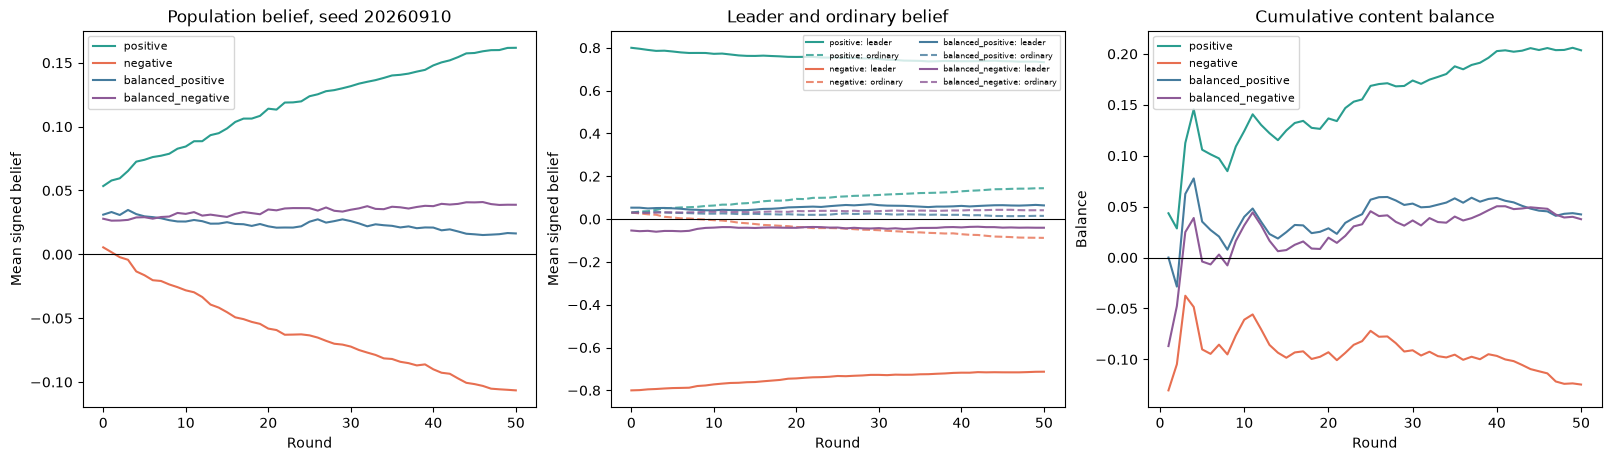

In [5]:
first_metrics = pd.concat(
    [run.round_metrics for run in FIRST_RUNS.values()],
    ignore_index=True,
)
colors = {
    "positive": "#2a9d8f",
    "negative": "#e76f51",
    "balanced_positive": "#457b9d",
    "balanced_negative": "#8d5a97",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for orientation in EXPERIMENT.orientations:
    frame = first_metrics.loc[first_metrics["orientation"] == orientation]
    axes[0].plot(frame["round"], frame["mean_signed_belief"], label=orientation, color=colors[orientation])
    axes[1].plot(frame["round"], frame["leader_mean_signed_belief"], color=colors[orientation], label=f"{orientation}: leader")
    axes[1].plot(frame["round"], frame["ordinary_mean_signed_belief"], color=colors[orientation], linestyle="--", alpha=0.8, label=f"{orientation}: ordinary")
    axes[2].plot(frame["round"], frame["cumulative_content_balance"], label=orientation, color=colors[orientation])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title=f"Population belief, seed {FIRST_SEED}", xlabel="Round", ylabel="Mean signed belief")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Leader and ordinary belief", xlabel="Round", ylabel="Mean signed belief")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(title="Cumulative content balance", xlabel="Round", ylabel="Balance")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=6, ncol=2)
axes[2].legend(fontsize=8)
plt.show()

## 6. Ten-seed exploratory experiment

In [6]:
ROUND_METRICS = run_opleader_experiment(EXPERIMENT)
FINAL_METRICS = final_condition_metrics(ROUND_METRICS)
FINAL_SUMMARY = summarize_final_conditions(FINAL_METRICS)
display(FINAL_METRICS.head(12))
display(FINAL_SUMMARY)

,seed,condition,orientation,round,message_count,exposure_count,leader_origination_rate,ordinary_origination_rate,leader_exposure_share,round_content_balance,cumulative_content_balance,mean_signed_belief,mean_absolute_belief,extremist_ratio,ordinary_mean_signed_belief,leader_mean_signed_belief,edge_count,mean_following_degree,homophily_ratio
0,20260910,balanced,balanced_pair_mean,50,25.0,86.0,0.066667,0.049485,0.162791,-0.080000,0.040000,0.027598,0.343111,0.025,0.028088,0.011749,1491.0,2.982,0.555667
1,20260910,negative,negative,50,25.0,86.0,0.066667,0.049485,0.162791,-0.200000,-0.124706,-0.106523,0.349193,0.018,-0.087772,-0.712820,1491.0,2.982,0.589537
2,20260910,positive,positive,50,25.0,86.0,0.066667,0.049485,0.162791,0.040000,0.203529,0.161753,0.366691,0.042,0.144091,0.732816,1491.0,2.982,0.656606
3,20260911,balanced,balanced_pair_mean,50,27.0,88.0,0.133333,0.051546,0.363636,-0.148148,-0.024713,-0.033767,0.342330,0.030,-0.034378,-0.014015,1491.0,2.982,0.563045
4,20260911,negative,negative,50,27.0,88.0,0.133333,0.051546,0.363636,-0.407407,-0.190805,-0.165747,0.371113,0.038,-0.148450,-0.725025,1491.0,2.982,0.631791
5,20260911,positive,positive,50,27.0,88.0,0.133333,0.051546,0.363636,0.185185,0.144828,0.103787,0.346708,0.032,0.085317,0.700976,1491.0,2.982,0.607646
6,20260912,balanced,balanced_pair_mean,50,21.0,123.0,0.333333,0.032990,0.674797,0.142857,-0.020698,-0.023055,0.322786,0.017,-0.024124,0.011501,1491.0,2.982,0.538229
7,20260912,negative,negative,50,21.0,123.0,0.333333,0.032990,0.674797,-0.238095,-0.164991,-0.143764,0.344944,0.020,-0.126920,-0.688377,1491.0,2.982,0.605634
8,20260912,positive,positive,50,21.0,123.0,0.333333,0.032990,0.674797,0.523810,0.129509,0.100193,0.328856,0.020,0.081278,0.711770,1491.0,2.982,0.581489
9,20260913,balanced,balanced_pair_mean,50,23.0,74.0,0.066667,0.045361,0.297297,-0.217391,-0.018541,0.003499,0.318298,0.022,0.003983,-0.012145,1491.0,2.982,0.541583


,condition,run_count,mean_signed_belief_mean,mean_signed_belief_std,mean_absolute_belief_mean,mean_absolute_belief_std,extremist_ratio_mean,extremist_ratio_std,ordinary_mean_signed_belief_mean,ordinary_mean_signed_belief_std,...,leader_exposure_share_mean,leader_exposure_share_std,cumulative_content_balance_mean,cumulative_content_balance_std,edge_count_mean,edge_count_std,mean_following_degree_mean,mean_following_degree_std,homophily_ratio_mean,homophily_ratio_std
0,balanced,10,-0.007937,0.025119,0.332450,0.008828,0.0256,0.005892,-0.008135,0.025568,...,0.391623,0.161078,-0.012079,0.038253,1491.0,0.0,2.982,0.0,0.551241,0.009253
1,negative,10,-0.130855,0.024509,0.345888,0.011777,0.0308,0.010031,-0.113129,0.024928,...,0.391623,0.161078,-0.165689,0.038942,1491.0,0.0,2.982,0.0,0.607109,0.014304
2,positive,10,0.114783,0.028928,0.344161,0.012609,0.0262,0.007084,0.096658,0.029325,...,0.391623,0.161078,0.139938,0.044882,1491.0,0.0,2.982,0.0,0.607042,0.029828


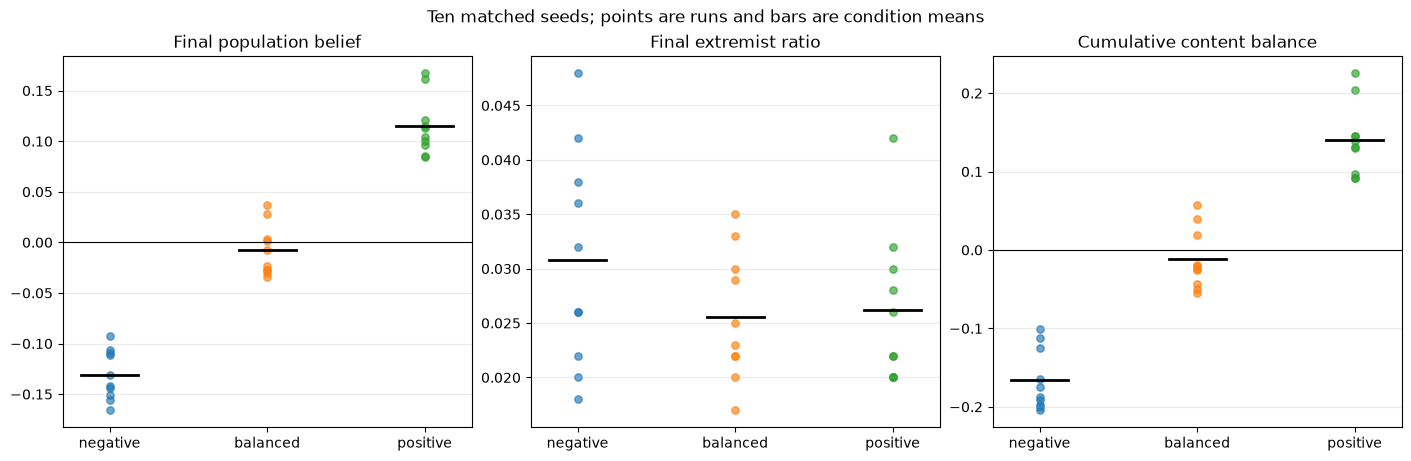

In [7]:
conditions = ["negative", "balanced", "positive"]
metrics_to_plot = [
    ("mean_signed_belief", "Final population belief"),
    ("extremist_ratio", "Final extremist ratio"),
    ("cumulative_content_balance", "Cumulative content balance"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
for axis, (metric, title) in zip(axes, metrics_to_plot):
    for position, condition in enumerate(conditions):
        values = FINAL_METRICS.loc[FINAL_METRICS["condition"] == condition, metric]
        axis.scatter(np.full(len(values), position), values, alpha=0.65, s=28)
        axis.plot([position - 0.18, position + 0.18], [values.mean(), values.mean()], color="black", linewidth=2)
    axis.set_xticks(range(len(conditions)), conditions)
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.25)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.8)
fig.suptitle("Ten matched seeds; points are runs and bars are condition means")
plt.show()

## 7. Executable scenario-boundary checks

In [8]:
reference_network = FIRST_RUNS["positive"].initialization.state.network
same_network = all(run.initialization.state.network == reference_network for run in FIRST_RUNS.values())
static_network = all(
    round_result.next_state.network == run.simulation_result.initial_state.network
    for run in FIRST_RUNS.values()
    for round_result in run.simulation_result.rounds
)
no_self_exposure = all(
    exposure.consumer_id != exposure.message.producer_id
    for run in FIRST_RUNS.values()
    for round_result in run.simulation_result.rounds
    for exposure in round_result.events.exposures
)
all_exposures_tied = all(
    exposure.message.producer_id in round_result.snapshot.network.eligible_producers(exposure.consumer_id)
    for run in FIRST_RUNS.values()
    for round_result in run.simulation_result.rounds
    for exposure in round_result.events.exposures
)
ledger = DIAGNOSTIC_FRAMES["positive"]["transitions"]
updates_reconstruct = np.allclose(ledger["a_after"], ledger["a_before"] + ledger["weighted_support"]) and np.allclose(ledger["b_after"], ledger["b_before"] + ledger["weighted_oppose"])
weights_reconstruct = np.allclose(
    ledger["weighted_support"],
    SIMULATION.evidence_weight * (ledger["ordinary_support_messages"] + MECHANISMS.leader_evidence_multiplier * ledger["leader_support_messages"]),
) and np.allclose(
    ledger["weighted_oppose"],
    SIMULATION.evidence_weight * (ledger["ordinary_oppose_messages"] + MECHANISMS.leader_evidence_multiplier * ledger["leader_oppose_messages"]),
)
checks = pd.DataFrame(
    [
        ("matched network across orientations", same_network),
        ("network remains static", static_network),
        ("self-exposure excluded", no_self_exposure),
        ("all exposures use directed ties", all_exposures_tied),
        ("capacity is universally nonbinding", SIMULATION.consumption_capacity == SIMULATION.agent_count - 1),
        ("Beta updates reconstruct", updates_reconstruct),
        ("source weights reconstruct", weights_reconstruct),
        ("40 runs x 51 snapshots retained", len(ROUND_METRICS) == 40 * 51),
        ("30 final condition rows retained", len(FINAL_METRICS) == 30),
    ],
    columns=["check", "passed"],
)
assert checks["passed"].all()
checks

,check,passed
0,matched network across orientations,True
1,network remains static,True
2,self-exposure excluded,True
3,all exposures use directed ties,True
4,capacity is universally nonbinding,True
5,Beta updates reconstruct,True
6,source weights reconstruct,True
7,40 runs x 51 snapshots retained,True
8,30 final condition rows retained,True


## Interpretation boundary

These runs establish software behavior and exploratory connected-framework patterns. They do not calibrate the leader parameters, validate the directed network empirically, or by themselves establish a clean causal `opleader - null` estimate while the interest-decay mismatch remains.